# Amazon Sales Data Analysis

## Exploratory Data Analysis (EDA)

### Objective

Analyze the cleaned Amazon Sales dataset to identify sales trends, product performance, fulfillment efficiency, customer behavior, and geographical distribution, and generate actionable business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Amazon_Sales_Cleaned (1).csv to Amazon_Sales_Cleaned (1).csv


In [4]:
df = pd.read_csv("Amazon_Sales_Cleaned (1).csv")

In [5]:
df.head()

,order_id,date,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b,fulfilled_by,year,month,month_number,day,day_name,quarter
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,False,Easy Ship,2022,April,4,30,Saturday,2
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085,IN,False,Easy Ship,2022,April,4,30,Saturday,2
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,True,Amazon,2022,April,4,30,Saturday,2
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,False,Easy Ship,2022,April,4,30,Saturday,2
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073,IN,False,Amazon,2022,April,4,30,Saturday,2


In [6]:
df.shape

(128579, 24)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128579 entries, 0 to 128578
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            128579 non-null  object 
 1   date                128579 non-null  object 
 2   status              128579 non-null  object 
 3   fulfilment          128579 non-null  object 
 4   sales_channel       128579 non-null  object 
 5   ship_service_level  128579 non-null  object 
 6   category            128579 non-null  object 
 7   size                128579 non-null  object 
 8   courier_status      128579 non-null  object 
 9   qty                 128579 non-null  int64  
 10  currency            128579 non-null  object 
 11  amount              128579 non-null  float64
 12  ship_city           128579 non-null  object 
 13  ship_state          128579 non-null  object 
 14  ship_postal_code    128579 non-null  int64  
 15  ship_country        128579 non-nul

## Business Overview

In [8]:
total_orders = df["order_id"].nunique()
total_revenue = df["amount"].sum()
total_quantity = df["qty"].sum()
average_order_value = df["amount"].mean()

summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Revenue",
        "Total Quantity Sold",
        "Average Order Value"
    ],
    "Value": [
        total_orders,
        round(total_revenue, 2),
        total_quantity,
        round(average_order_value, 2)
    ]
})

summary

,Metric,Value
0,Total Orders,120106.00
1,Total Revenue,78496786.39
2,Total Quantity Sold,116330.00
3,Average Order Value,610.49


### Business Insight

The summary above provides a high-level overview of the sales performance, including the total number of unique orders, revenue generated, quantity sold, and average order value.

## Sales Trend Analysis

In [9]:
monthly_sales = (
    df.groupby(["month_number", "month"], as_index=False)
      .agg(
          Total_Revenue=("amount", "sum"),
          Total_Orders=("order_id", "nunique")
      )
      .sort_values("month_number")
)

monthly_sales

,month_number,month,Total_Revenue,Total_Orders
0,3,March,101683.85,158
1,4,April,28742816.41,45657
2,5,May,26226476.75,39180
3,6,June,23425809.38,35111


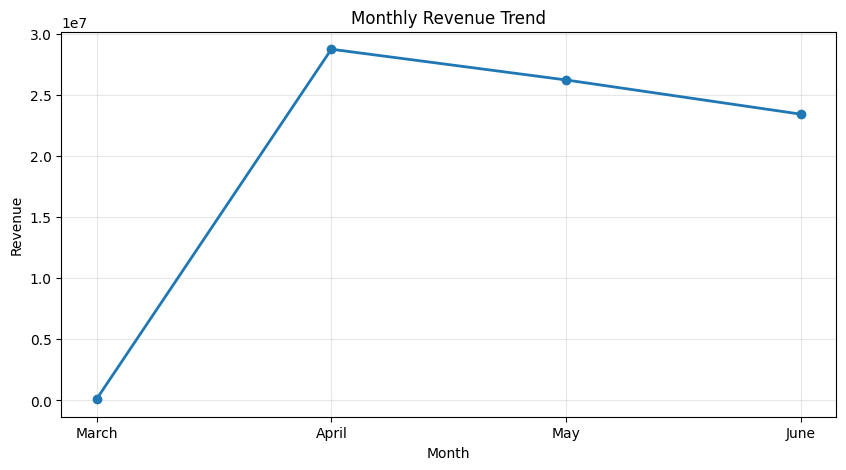

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["Total_Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)

plt.show()

In [11]:
monthly_sales

,month_number,month,Total_Revenue,Total_Orders
0,3,March,101683.85,158
1,4,April,28742816.41,45657
2,5,May,26226476.75,39180
3,6,June,23425809.38,35111


### Business Insight

The monthly revenue trend highlights how sales fluctuate over time, helping identify peak and low-performing months. These insights support demand forecasting, inventory planning, and marketing decisions.

## Order Status Analysis

In [12]:
status_analysis = (
    df.groupby("status", as_index=False)
      .agg(
          Orders=("order_id", "nunique"),
          Revenue=("amount", "sum")
      )
      .sort_values("Orders", ascending=False)
)

status_analysis

,status,Orders,Revenue
3,Shipped,72627,50268420.00
5,Shipped - Delivered to Buyer,26521,18619610.00
0,Cancelled,17166,6910831.39
10,Shipped - Returned to Seller,1850,1269245.00
8,Shipped - Picked Up,918,661252.00
1,Pending,584,430271.00
2,Pending - Waiting for Pick Up,262,192138.00
11,Shipped - Returning to Seller,130,107620.00
7,Shipped - Out for Delivery,32,26971.00
9,Shipped - Rejected by Buyer,11,7295.00


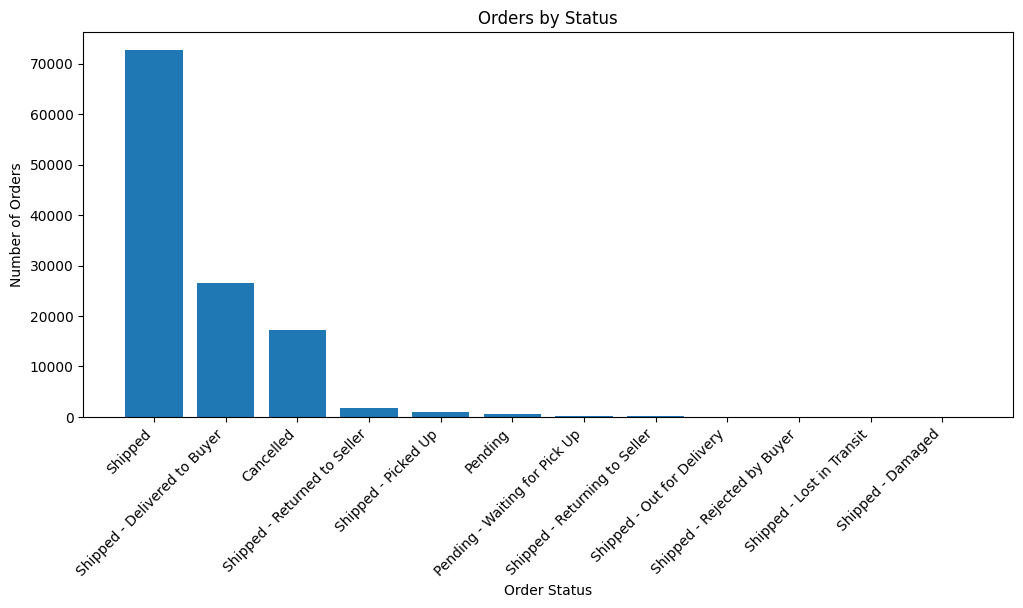

In [13]:
plt.figure(figsize=(12,5))

plt.bar(
    status_analysis["status"],
    status_analysis["Orders"]
)

plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")

plt.show()

### Business Insight

Most orders were successfully shipped or delivered, while a smaller proportion were cancelled or remained pending. Monitoring cancellation and pending orders can help improve operational efficiency and customer satisfaction.

## Product Category Analysis

In [15]:
category_analysis = (
    df.groupby("category", as_index=False)
      .agg(
          Orders=("order_id", "nunique"),
          Quantity=("qty", "sum"),
          Revenue=("amount", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

category_analysis

,category,Orders,Quantity,Revenue
5,T-shirt,47718,45165,39154132.17
2,Shirt,46438,44903,21269768.70
0,Blazzer,14977,13930,11208506.12
6,Trousers,10136,9885,5341305.30
1,Perfume,1146,1051,789419.66
7,Wallet,893,844,458408.18
4,Socks,408,397,150397.50
3,Shoes,144,152,123933.76
8,Watch,2,3,915.00


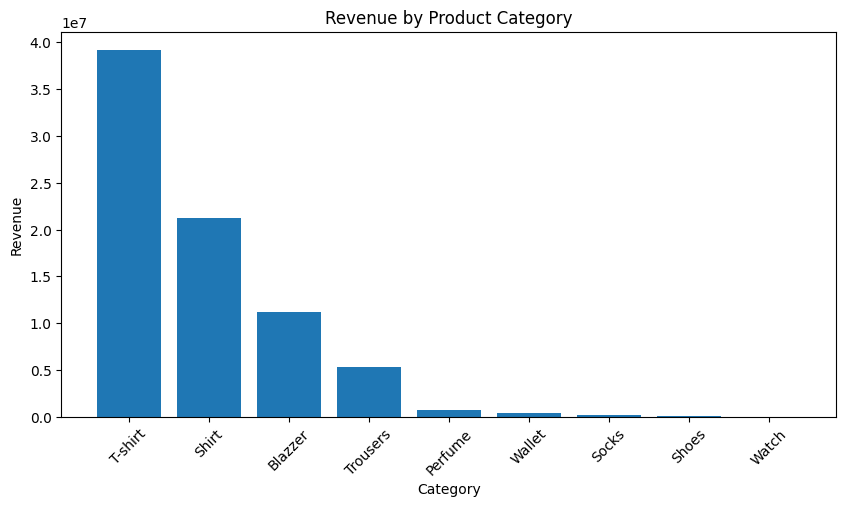

In [16]:
plt.figure(figsize=(10,5))

plt.bar(
    category_analysis["category"],
    category_analysis["Revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

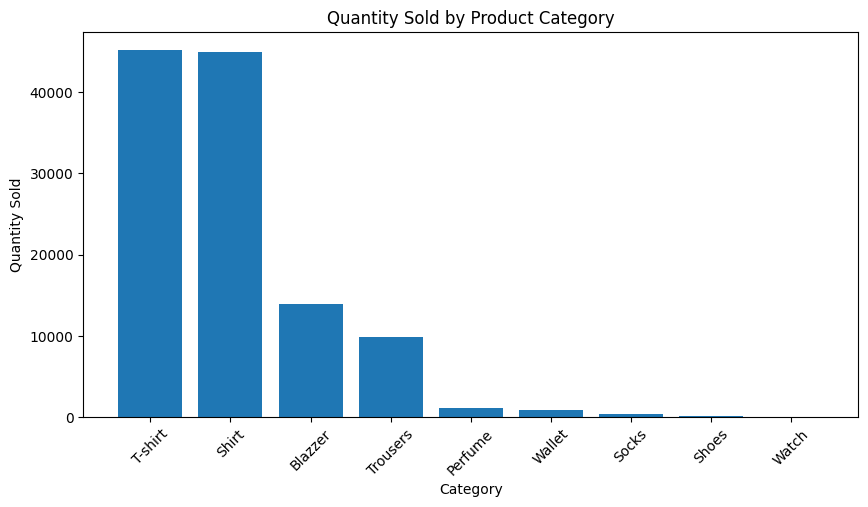

In [17]:
plt.figure(figsize=(10,5))

plt.bar(
    category_analysis["category"],
    category_analysis["Quantity"]
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.show()

### Business Insight

Product categories contribute differently to both revenue and sales volume. Comparing revenue and quantity helps identify whether high-performing categories are driven by higher demand or higher selling prices, supporting better inventory and product planning.

## Product Size Analysis

In [18]:
size_analysis = (
    df.groupby("size", as_index=False)
      .agg(
          Orders=("order_id", "nunique"),
          Quantity=("qty", "sum"),
          Revenue=("amount", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

size_analysis

,size,Orders,Quantity,Revenue
6,M,21364,20096,13678295.13
5,L,20698,19652,13023938.84
8,XL,19537,18587,12240095.38
10,XXL,16860,16201,10452621.64
7,S,16002,15004,10414943.18
0,3XL,13571,13328,9026104.92
9,XS,10400,9815,6952253.10
4,Free,2185,2050,1372676.60
3,6XL,680,687,576249.33
2,5XL,525,512,425156.63


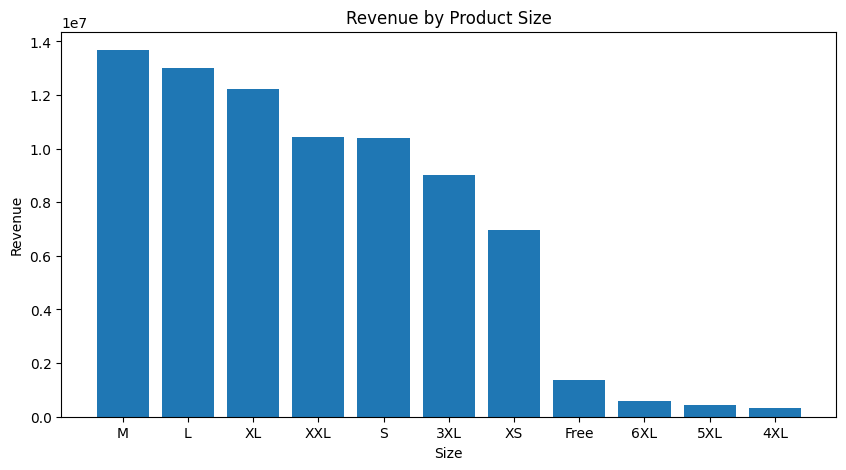

In [19]:
plt.figure(figsize=(10,5))

plt.bar(
    size_analysis["size"],
    size_analysis["Revenue"]
)

plt.title("Revenue by Product Size")
plt.xlabel("Size")
plt.ylabel("Revenue")

plt.show()

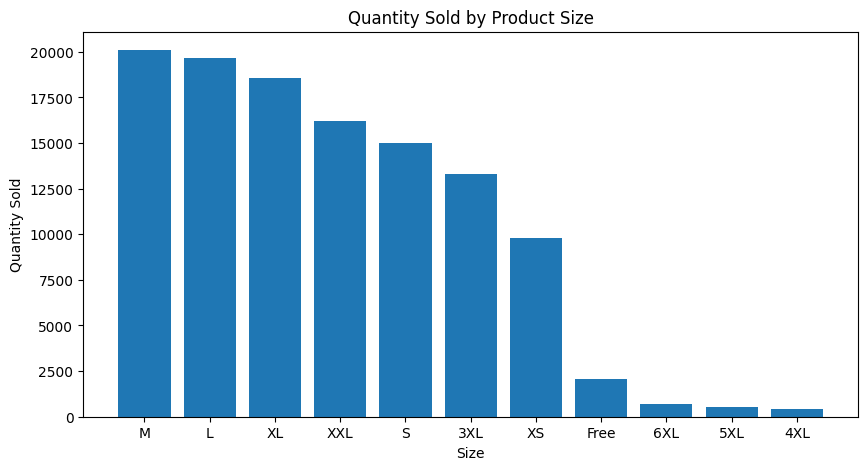

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    size_analysis["size"],
    size_analysis["Quantity"]
)

plt.title("Quantity Sold by Product Size")
plt.xlabel("Size")
plt.ylabel("Quantity Sold")

plt.show()

### Business Insight

Medium, Large, and Extra Large sizes contribute significantly to overall sales and revenue. Understanding customer size preferences helps optimize inventory allocation and reduce stock shortages for high-demand sizes.

## Fulfilment Analysis

In [21]:
fulfilment_analysis = (
    df.groupby("fulfilment", as_index=False)
      .agg(
          Orders=("order_id", "nunique"),
          Revenue=("amount", "sum")
      )
)

fulfilment_analysis

,fulfilment,Orders,Revenue
0,Amazon,83783,54262165.00
1,Merchant,36323,24234621.39


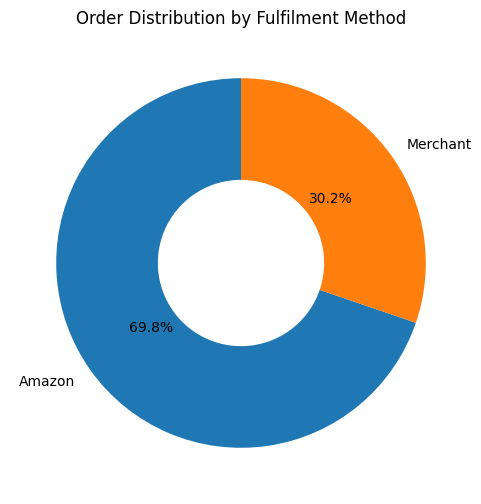

In [24]:
plt.figure(figsize=(6,6))

plt.pie(
    fulfilment_analysis["Orders"],
    labels=fulfilment_analysis["fulfilment"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.55}
)

plt.title("Order Distribution by Fulfilment Method")

plt.show()

### Business Insight

Amazon fulfilment handles the majority of customer orders, indicating a strong dependence on Amazon's logistics network. Merchant fulfilment represents a smaller share and can be monitored separately to evaluate operational performance.

## Sales Channel Analysis

In [25]:
sales_channel_analysis = (
    df.groupby("sales_channel", as_index=False)
      .agg(
          Orders=("order_id", "nunique"),
          Revenue=("amount", "sum")
      )
)

sales_channel_analysis

,sales_channel,Orders,Revenue
0,Amazon.in,120105,78496786.39
1,Non-Amazon,1,0.00


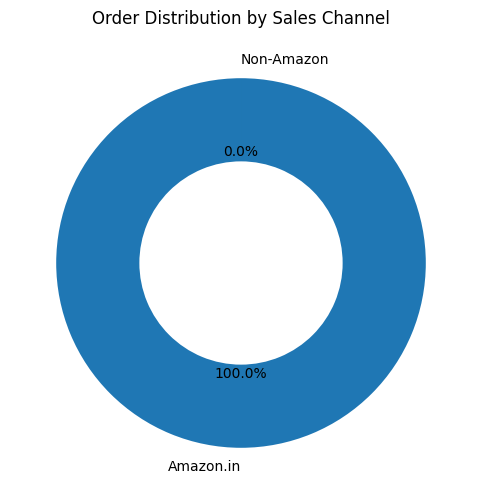

In [26]:
plt.figure(figsize=(6,6))

plt.pie(
    sales_channel_analysis["Orders"],
    labels=sales_channel_analysis["sales_channel"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.45}
)

plt.title("Order Distribution by Sales Channel")

plt.show()

### Business Insight

Amazon.in is the dominant sales channel, accounting for **120,105 orders** and generating **₹78.50 million** in revenue. In comparison, the Non-Amazon channel contributed only **one order** with no recorded revenue. This indicates that the business is almost entirely dependent on Amazon.in for sales, making it the primary platform for customer acquisition and revenue generation.

## Courier Status Analysis

In [27]:
courier_analysis = (
    df.groupby("courier_status", as_index=False)
      .agg(
          Orders=("order_id", "nunique"),
          Revenue=("amount", "sum")
      )
      .sort_values("Orders", ascending=False)
)

courier_analysis

,courier_status,Orders,Revenue
2,Shipped,102102,70971225.00
1,On the Way,6375,3185870.39
3,Unshipped,6066,4339691.00
0,Cancelled,5573,0.00


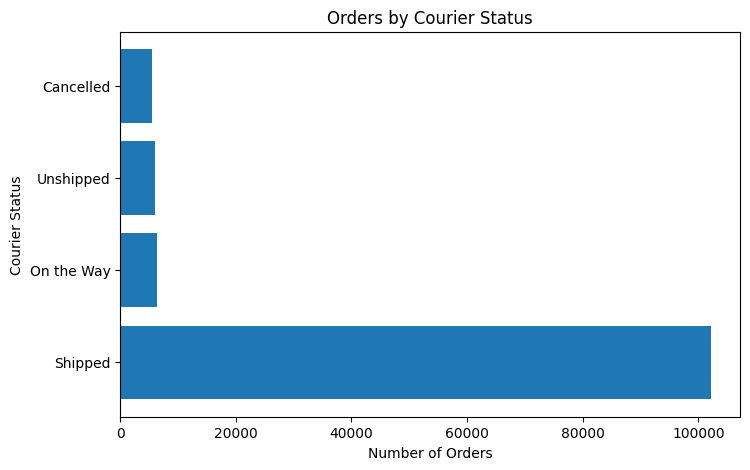

In [28]:
plt.figure(figsize=(8,5))

plt.barh(
    courier_analysis["courier_status"],
    courier_analysis["Orders"]
)

plt.title("Orders by Courier Status")
plt.xlabel("Number of Orders")
plt.ylabel("Courier Status")

plt.show()

### Business Insight

The majority of orders have been successfully shipped, indicating efficient order fulfillment. A smaller proportion of orders remain unshipped or cancelled, highlighting areas where operational improvements could reduce delivery delays and order cancellations.

## B2B vs B2C Analysis

In [29]:
b2b_analysis = (
    df.groupby("b2b", as_index=False)
      .agg(
          Orders=("order_id", "nunique"),
          Revenue=("amount", "sum")
      )
)

b2b_analysis["Customer_Type"] = b2b_analysis["b2b"].map({
    False: "B2C",
    True: "B2B"
})

b2b_analysis

,b2b,Orders,Revenue,Customer_Type
0,False,119312,77905565.60,B2C
1,True,794,591220.79,B2B


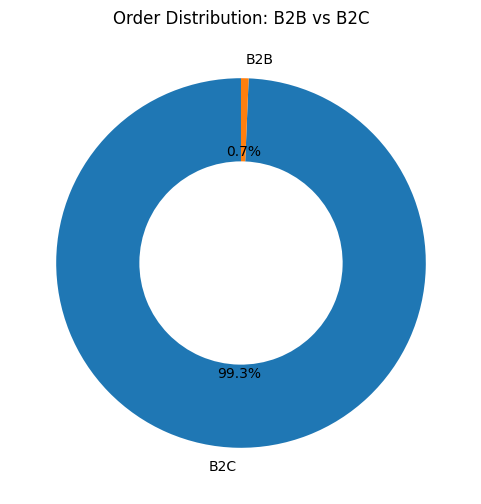

In [30]:
plt.figure(figsize=(6,6))

plt.pie(
    b2b_analysis["Orders"],
    labels=b2b_analysis["Customer_Type"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.45}
)

plt.title("Order Distribution: B2B vs B2C")

plt.show()

### Business Insight

The customer base is predominantly B2C, contributing the overwhelming majority of orders. B2B transactions represent only a small share, indicating that the business primarily serves individual consumers while maintaining limited business-to-business sales.

## Top 10 States by Revenue

In [31]:
state_analysis = (
    df.groupby("ship_state", as_index=False)
      .agg(
          Orders=("order_id", "nunique"),
          Revenue=("amount", "sum")
      )
      .sort_values("Revenue", ascending=False)
      .head(10)
)

state_analysis

,ship_state,Orders,Revenue
28,MAHARASHTRA,20756,13318966.38
23,KARNATAKA,16162,10465387.03
57,TELANGANA,10394,6909670.08
59,UTTAR PRADESH,10057,6814126.08
56,TAMIL NADU,10507,6510503.73
14,DELHI,6347,4228503.97
24,KERALA,6097,3821997.58
62,WEST BENGAL,5645,3503223.44
1,ANDHRA PRADESH,4970,3214859.86
19,HARYANA,4134,2879146.99


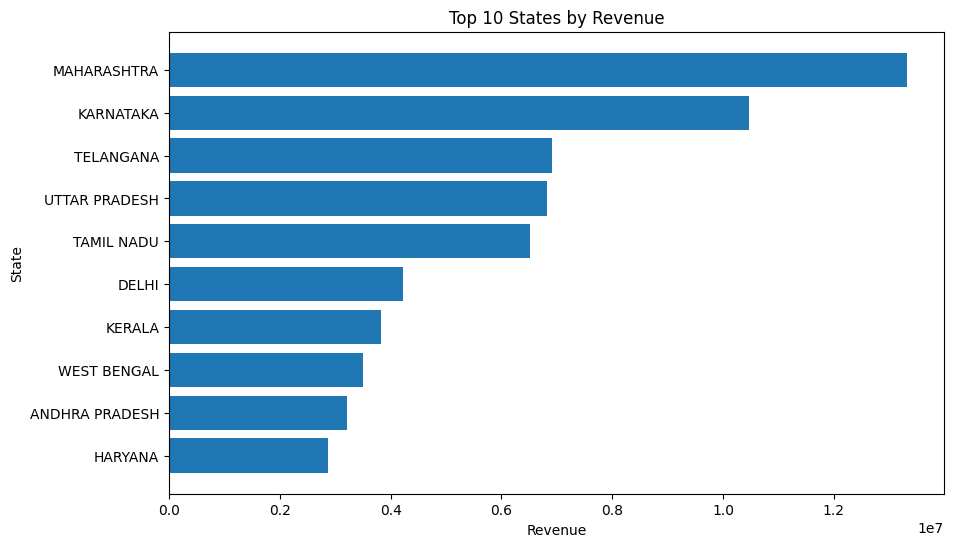

In [32]:
plt.figure(figsize=(10,6))

plt.barh(
    state_analysis["ship_state"],
    state_analysis["Revenue"]
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.show()

### Business Insight

The top-performing states contribute a significant share of the overall revenue, indicating strong customer demand in these regions. These states should be prioritized for inventory planning, targeted marketing campaigns, and customer retention strategies to maximize business growth.

## Top 10 Cities by Revenue

In [33]:
city_analysis = (
    df.groupby("ship_city", as_index=False)
      .agg(
          Orders=("order_id", "nunique"),
          Revenue=("amount", "sum")
      )
      .sort_values("Revenue", ascending=False)
      .head(10)
)

city_analysis

,ship_city,Orders,Revenue
775,BENGALURU,10441,6836614.65
2904,HYDERABAD,7404,4941790.25
4793,MUMBAI,5645,3696704.04
5391,NEW DELHI,5425,3608277.78
1464,CHENNAI,4925,3098745.74
6156,PUNE,3593,2337978.18
3710,KOLKATA,2246,1412815.87
2618,GURUGRAM,1768,1220562.74
7583,THANE,1612,1003878.29
4395,LUCKNOW,1393,933926.34


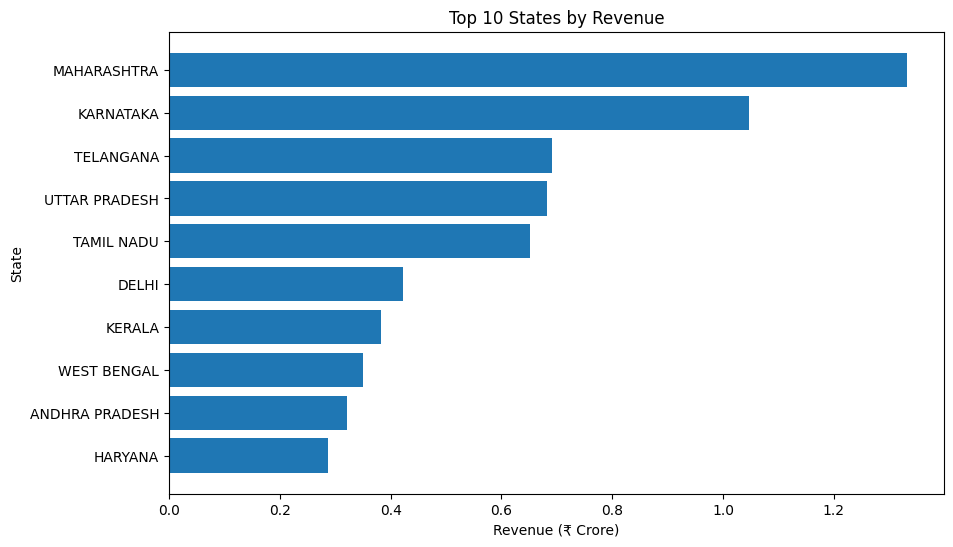

In [35]:
state_analysis["Revenue_Cr"] = state_analysis["Revenue"] / 10000000

plt.figure(figsize=(10,6))

plt.barh(
    state_analysis["ship_state"],
    state_analysis["Revenue_Cr"]
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue (₹ Crore)")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.show()

### Business Insight

The top-performing cities contribute a substantial portion of the total revenue, reflecting strong customer demand in urban markets. These locations present opportunities for focused marketing campaigns, faster delivery services, and optimized inventory allocation to further enhance sales performance.

## Revenue Distribution Analysis

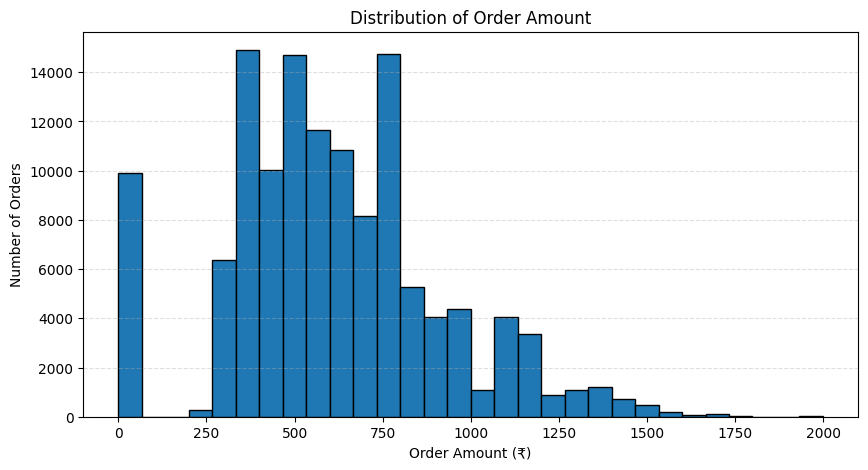

In [40]:
plt.figure(figsize=(10,5))

plt.hist(
    df[df["amount"] <= 2000]["amount"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Order Amount")
plt.xlabel("Order Amount (₹)")
plt.ylabel("Number of Orders")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Business Insight

The revenue distribution shows how order values are spread across transactions. It helps identify the most common purchase value range and detect high-value or unusually low-value orders that may influence overall sales performance.

## Monthly Order Trend

In [41]:
monthly_orders = (
    df.groupby(["month_number", "month"], as_index=False)
      .agg(
          Orders=("order_id", "nunique")
      )
      .sort_values("month_number")
)

monthly_orders

,month_number,month,Orders
0,3,March,158
1,4,April,45657
2,5,May,39180
3,6,June,35111


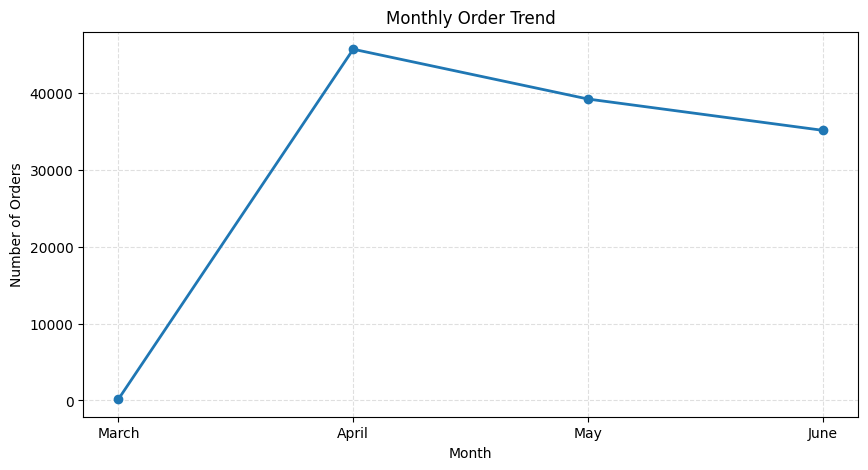

In [42]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders["month"],
    monthly_orders["Orders"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.grid(linestyle="--", alpha=0.4)

plt.show()

### Business Insight

The monthly order trend highlights changes in customer demand over time. Identifying months with peak and lower order volumes helps businesses plan inventory, staffing, and promotional campaigns more effectively.

## Top 10 Products by Quantity Sold

In [44]:
product_analysis = (
    df.groupby("category", as_index=False)
      .agg(
          Quantity=("qty", "sum"),
          Revenue=("amount", "sum")
      )
      .sort_values("Quantity", ascending=False)
)

product_analysis["Revenue_Cr"] = product_analysis["Revenue"] / 10000000

product_analysis

,category,Quantity,Revenue,Revenue_Cr
5,T-shirt,45165,39154132.17,3.915413
2,Shirt,44903,21269768.70,2.126977
0,Blazzer,13930,11208506.12,1.120851
6,Trousers,9885,5341305.30,0.534131
1,Perfume,1051,789419.66,0.078942
7,Wallet,844,458408.18,0.045841
4,Socks,397,150397.50,0.015040
3,Shoes,152,123933.76,0.012393
8,Watch,3,915.00,0.000092


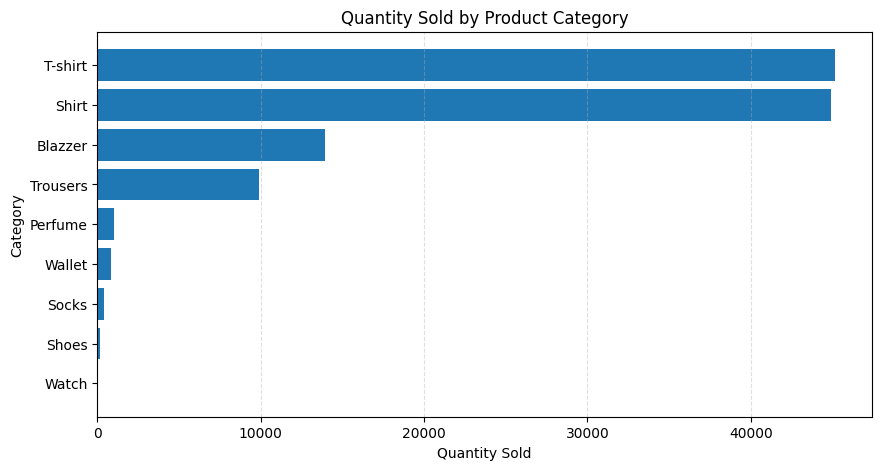

In [45]:
plt.figure(figsize=(10,5))

plt.barh(
    product_analysis["category"],
    product_analysis["Quantity"]
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Quantity Sold")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

## Conclusion

The exploratory data analysis provided valuable insights into Amazon's sales performance, customer purchasing patterns, product demand, fulfillment efficiency, and geographical distribution.

#### Key Findings

- Amazon.in is the primary sales channel, contributing almost all orders and revenue.
- Amazon Fulfilment manages the majority of customer orders.
- T-shirts and Shirts are the highest-performing product categories.
- Medium, Large, and XL are the most frequently purchased sizes.
- Maharashtra, Karnataka, and Tamil Nadu are among the highest revenue-generating states.
- Metropolitan cities contribute a significant share of total sales.
- Most orders are successfully shipped, indicating an efficient fulfillment process.
- The business primarily serves B2C customers.
- Most customer orders fall within a moderate price range, with only a few high-value transactions.

Overall, the analysis highlights strong sales performance across major urban regions while identifying opportunities to further improve inventory planning, delivery efficiency, and customer experience.